<a href="https://colab.research.google.com/github/jelaenas/CESISTA-KJ-DSC1107/blob/main/CESISTA%2C%20KJ%20-%20FA%204%20GROUP%2010%20DSC%201107.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[https://github.com/jelaenas/CESISTA-KJ-DSC1107/blob/main/FA_4_GROUP_10_DSC_1107.ipynb](https://github.com/jelaenas/CESISTA-KJ-DSC1107/blob/main/FA_4_GROUP_10_DSC_1107.ipynb)

In [ ]:
library(tidyverse)
install.packages("caret")
library(caret)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift




In [19]:
install.packages("glmnet")
library(glmnet)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘RcppEigen’


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-10



In [25]:
library(rpart)
install.packages("rpart.plot")
library(rpart.plot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [38]:
install.packages("randomForest")
library(randomForest)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin




# Part 1: Data Preparation (4 points)

**Import (2 points)**

Load the dataset into a tibble called adult_raw.

Display the structure of the dataset.

**Tidy & Explore (2 points)**

Check for missing values (? entries should be handled).

Convert categorical variables into factors.

Provide summary statistics.

In [ ]:
# Import

adult_raw <- read.csv("adult.csv")

str(adult_raw)

'data.frame':	48842 obs. of  15 variables:
 $ age           : int  39 50 38 53 28 37 49 52 31 42 ...
 $ workclass     : chr  "State-gov" "Self-emp-not-inc" "Private" "Private" ...
 $ fnlwgt        : int  77516 83311 215646 234721 338409 284582 160187 209642 45781 159449 ...
 $ education     : chr  "Bachelors" "Bachelors" "HS-grad" "11th" ...
 $ education.num : int  13 13 9 7 13 14 5 9 14 13 ...
 $ marital.status: chr  "Never-married" "Married-civ-spouse" "Divorced" "Married-civ-spouse" ...
 $ occupation    : chr  "Adm-clerical" "Exec-managerial" "Handlers-cleaners" "Handlers-cleaners" ...
 $ relationship  : chr  "Not-in-family" "Husband" "Not-in-family" "Husband" ...
 $ race          : chr  "White" "White" "White" "Black" ...
 $ sex           : chr  "Male" "Male" "Male" "Male" ...
 $ capital.gain  : int  2174 0 0 0 0 0 0 0 14084 5178 ...
 $ capital.loss  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hours.per.week: int  40 13 40 40 40 40 16 45 50 40 ...
 $ native.country: chr  "United-States" "Uni

In [ ]:
#Tidy & Explore

sum(adult_raw == "?", na.rm = TRUE) #there are 4262 ? values

adult_NA <- adult_raw %>%
  mutate(across(where(is.character), ~na_if(.x, "?")))

sum(adult_NA == "?", na.rm = TRUE) #0 values now
sum(is.na(adult_NA)) #4262 as ? values are now NA

adult_clean <- adult_NA %>%
  drop_na()

sum(is.na(adult_clean)) #0 values now

adult <- adult_clean %>%
  select(age, workclass, education, occupation,
         hours.per.week, capital.gain, capital.loss,
         sex, race, marital.status, income) %>%
  mutate(across(where(is.character), as.factor))

# Summary statistics
summary(adult)
str(adult)

[1] 4262

[1] 0

[1] 4262

[1] 0

      age                   workclass            education    
 Min.   :17.00   Private         :33496   HS-grad     :15123  
 1st Qu.:28.00   Self-emp-not-inc: 3820   Some-college:10265  
 Median :37.00   Local-gov       : 3110   Bachelors   : 7714  
 Mean   :38.55   State-gov       : 1962   Masters     : 2561  
 3rd Qu.:47.00   Self-emp-inc    : 1653   Assoc-voc   : 1986  
 Max.   :90.00   Federal-gov     : 1415   11th        : 1685  
                 (Other)         :  987   (Other)     : 7109  
           occupation    hours.per.week   capital.gain    capital.loss    
 Prof-specialty : 6070   Min.   : 1.00   Min.   :    0   Min.   :   0.00  
 Craft-repair   : 6043   1st Qu.:40.00   1st Qu.:    0   1st Qu.:   0.00  
 Exec-managerial: 6012   Median :40.00   Median :    0   Median :   0.00  
 Adm-clerical   : 5562   Mean   :40.74   Mean   : 1088   Mean   :  88.21  
 Sales          : 5438   3rd Qu.:45.00   3rd Qu.:    0   3rd Qu.:   0.00  
 Other-service  : 4840   Max.   :99.00   Max. 

'data.frame':	46443 obs. of  11 variables:
 $ age           : int  39 50 38 53 28 37 49 52 31 42 ...
 $ workclass     : Factor w/ 9 levels "","Federal-gov",..: 8 7 5 5 5 5 5 7 5 5 ...
 $ education     : Factor w/ 16 levels "10th","11th",..: 10 10 12 2 10 13 7 12 13 10 ...
 $ occupation    : Factor w/ 15 levels "","Adm-clerical",..: 2 5 7 7 11 5 9 5 11 5 ...
 $ hours.per.week: int  40 13 40 40 40 40 16 45 50 40 ...
 $ capital.gain  : int  2174 0 0 0 0 0 0 0 14084 5178 ...
 $ capital.loss  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ sex           : Factor w/ 2 levels "Female","Male": 2 2 2 2 1 1 1 2 1 2 ...
 $ race          : Factor w/ 5 levels "Amer-Indian-Eskimo",..: 5 5 5 3 3 5 3 5 5 5 ...
 $ marital.status: Factor w/ 7 levels "Divorced","Married-AF-spouse",..: 5 3 1 3 3 3 4 3 5 3 ...
 $ income        : Factor w/ 4 levels "<=50K","<=50K.",..: 1 1 1 1 1 1 1 3 3 3 ...


# Part 2: Logistic Regression (6 points)

Fit a logistic regression model predicting income. (2 pts)

Identify significant predictors. (2 pts)

Compute classification accuracy using a 0.5 threshold. (2 pts)

In [ ]:
adult$income <- ifelse(adult$income == ">50K", 1, 0)

adult_model <- glm (income ~ ., data = adult, family = "binomial")

summary(adult_model)

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = income ~ ., family = "binomial", data = adult)

Coefficients: (1 not defined because of singularities)
                                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)                         -2.136e+01  1.117e+02  -0.191 0.848262    
age                                  2.019e-02  1.364e-03  14.808  < 2e-16 ***
workclassFederal-gov                 1.559e+01  1.117e+02   0.140 0.888927    
workclassLocal-gov                   1.514e+01  1.117e+02   0.136 0.892144    
workclassNever-worked                2.250e+00  2.207e+03   0.001 0.999187    
workclassPrivate                     1.525e+01  1.117e+02   0.137 0.891379    
workclassSelf-emp-inc                1.524e+01  1.117e+02   0.137 0.891416    
workclassSelf-emp-not-inc            1.488e+01  1.117e+02   0.133 0.893958    
workclassState-gov                   1.499e+01  1.117e+02   0.134 0.893193    
workclassWithout-pay                -2.575e-01  7.726e+02   0.000 0.999734    
educati

In [22]:
coeffs <- summary(adult_model)$coefficients

significant_preds1 <- rownames(coeffs)[coeffs[, "Pr(>|z|)"] < 0.05]
significant_preds2 <- significant_preds1[significant_preds1 != "(Intercept)"]

cat("The significant predictors are: \n")
significant_preds2
length(significant_preds2)

The significant predictors are: 


[1] "age"                              "education5th-6th"                
 [3] "education7th-8th"                 "educationAssoc-acdm"             
 [5] "educationAssoc-voc"               "educationBachelors"              
 [7] "educationDoctorate"               "educationHS-grad"                
 [9] "educationMasters"                 "educationProf-school"            
[11] "educationSome-college"            "occupationExec-managerial"       
[13] "occupationFarming-fishing"        "occupationHandlers-cleaners"     
[15] "occupationMachine-op-inspct"      "occupationOther-service"         
[17] "occupationPriv-house-serv"        "occupationProf-specialty"        
[19] "occupationProtective-serv"        "occupationSales"                 
[21] "occupationTech-support"           "hours.per.week"                  
[23] "capital.gain"                     "capital.loss"                    
[25] "sexMale"                          "raceWhite"                       
[27] "marital.statusMarried-AF-spouse"  "marital.statusMarried-civ-spouse"
[29] "marital.statusNever-married"

[1] 29

In [ ]:
prob <- predict(adult_model, type = "response")
pred <- ifelse(prob > 0.5, 1, 0)

# Accuracy
mean(pred == adult$income)

[1] 0.8494283

# Part 3: Regression in High Dimensions (4 points)
In this section, you will transform the UCI Adult Income Dataset into a high-dimensional dataset.

Convert all categorical variables into dummy variables (one-hot encoding). (1 pt)

Store the transformed dataset as adult_hd.

Report the number of observations (n) and predictors (p). (1 pt)

Explain why this dataset can now be considered high-dimensional. (1 pt)

Fit a standard logistic regression model using adult_hd.

Describe any issues encountered, such as: multicollinearity, unstable coefficients, overfitting

In [16]:
dummies <- dummyVars(" ~ .", data = adult %>% select(-income))

adult_hd_features <- data.frame(predict(dummies, newdata = adult))

adult_hd <- cbind(adult_hd_features, income = adult$income)

n <- nrow(adult_hd)
p <- ncol(adult_hd) -1

cat("Number of observations (n):", n, "\n")
cat("Number of predictors (p):", p, "\n")

Number of observations (n): 46443 
Number of predictors (p): 59 


**Explain why this dataset can now be considered high-dimensional: As seen the number of observations remained 46,443 while the number of predictors went from 10 to 59. Although the number of observations (n) is still greater than the number of predictors (p), the adult_hd dataset is still conisdered to be high-dimensional as the increase in predictors and the amount of sparse variables increases the model's complexity. Variables such as workclass and education, which have many categories, are further expanded into multiple binary indicators, which ultimaately leads to a larger and sparser feature space.**

**Describe any issues encountered, such as: multicollinearity, unstable coefficients, overfitting: (1) Multicollinearity - as dummy variables are derived from the same categorical feature it results in these dummy variables being highly correlatedto one another. This then causes edundancy and instability when computing for coefficients. (2) Non-convergence - the warning "glm.fit: algorithm did not converge" shows up in the code, which means that there might not be stable parameter estimates. (3) Perfect Separation - some predictors appear to perfectly separate the outcome classes, which makes coefficient either unreliable or infinite. (4) Unstable and inflated coefficients - extremely large coefficient values, as seen in the output, can indicate numerical instability.**

In [17]:
hd_model <- glm(income ~ ., data = adult_hd, family = "binomial")

summary(hd_model)

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = income ~ ., family = "binomial", data = adult_hd)

Coefficients: (6 not defined because of singularities)
                                       Estimate Std. Error  z value Pr(>|z|)
(Intercept)                          -5.749e+12  2.565e+13   -0.224 0.822630
age                                   2.021e-02  1.366e-03   14.793  < 2e-16
workclass.                            5.749e+12  2.565e+13    0.224 0.822630
workclass.Federal.gov                 5.749e+12  2.565e+13    0.224 0.822630
workclass.Local.gov                   5.749e+12  2.565e+13    0.224 0.822630
workclass.Never.worked               -4.498e+15  2.565e+13 -175.387  < 2e-16
workclass.Private                     5.749e+12  2.565e+13    0.224 0.822630
workclass.Self.emp.inc                5.749e+12  2.565e+13    0.224 0.822630
workclass.Self.emp.not.inc            5.749e+12  2.565e+13    0.224 0.822630
workclass.State.gov                   5.749e+12  2.565e+13    0.224 0.822630
workclass.Without.pay     

# Part 4: Ridge and Lasso Regression (6 points)

In this section, you will use the same high-dimensional dataset (adult_hd) created in Part 3.

Instructions:

Using adult_hd, fit a Ridge regression model with cross-validation to determine the optimal lambda. (2 pts)

Using the same dataset, fit a Lasso regression model with cross-validation. (2 pts)

Identify which variables are retained (non-zero coefficients) in the Lasso model. (1 pt)

Compare Ridge vs Lasso in the context of the issues observed in Part 3: How do they address multicollinearity? How do they affect model complexity? (1 pt)

In [23]:
x <- as.matrix(adult_hd %>% select(-income))
y <- adult_hd$income

ridge_cv <- cv.glmnet(x, y, alpha = 0)

best_lambda_ridge <- ridge_cv$lambda.min
cat("The optimal lambda for Ridge regression is:", best_lambda_ridge, "\n" )

lasso_cv <- cv.glmnet(x, y, alpha = 1)

best_lambda_lasso <- lasso_cv$lambda.min
cat("The optimal lambda for Lasso regression is:", best_lambda_lasso, "\n" )


lasso_coef <- coef(lasso_cv, s = "lambda.min")

selected_vars <- rownames(lasso_coef)[lasso_coef[,1] != 0]
selected_vars <- selected_vars[selected_vars != "(Intercept)"]

cat("The variables retained in the lasso model are: \n")
selected_vars
length(selected_vars)

The optimal lambda for Ridge regression is: 0.01264714 
The optimal lambda for Lasso regression is: 0.0001711219 
The variables retained in the lasso model are: 


[1] "age"                                 
 [2] "workclass."                          
 [3] "workclass.Federal.gov"               
 [4] "workclass.Never.worked"              
 [5] "workclass.Private"                   
 [6] "workclass.Self.emp.inc"              
 [7] "workclass.Self.emp.not.inc"          
 [8] "workclass.State.gov"                 
 [9] "workclass.Without.pay"               
[10] "education.10th"                      
[11] "education.11th"                      
[12] "education.12th"                      
[13] "education.1st.4th"                   
[14] "education.5th.6th"                   
[15] "education.7th.8th"                   
[16] "education.9th"                       
[17] "education.Assoc.acdm"                
[18] "education.Assoc.voc"                 
[19] "education.Bachelors"                 
[20] "education.Doctorate"                 
[21] "education.HS.grad"                   
[22] "education.Masters"                   
[23] "education.Preschool"                 
[24] "education.Prof.school"               
[25] "occupation.Adm.clerical"             
[26] "occupation.Armed.Forces"             
[27] "occupation.Craft.repair"             
[28] "occupation.Exec.managerial"          
[29] "occupation.Farming.fishing"          
[30] "occupation.Handlers.cleaners"        
[31] "occupation.Machine.op.inspct"        
[32] "occupation.Other.service"            
[33] "occupation.Priv.house.serv"          
[34] "occupation.Prof.specialty"           
[35] "occupation.Protective.serv"          
[36] "occupation.Sales"                    
[37] "occupation.Tech.support"             
[38] "occupation.Transport.moving"         
[39] "hours.per.week"                      
[40] "capital.gain"                        
[41] "capital.loss"                        
[42] "sex.Female"                          
[43] "race.Amer.Indian.Eskimo"             
[44] "race.Asian.Pac.Islander"             
[45] "race.Other"                          
[46] "race.White"                          
[47] "marital.status.Divorced"             
[48] "marital.status.Married.AF.spouse"    
[49] "marital.status.Married.civ.spouse"   
[50] "marital.status.Married.spouse.absent"
[51] "marital.status.Never.married"        
[52] "marital.status.Widowed"

[1] 52

**Compare Ridge vs Lasso in the context of the issues observed in Part 3: How do they address multicollinearity? How do they affect model complexity?**

**Ridge regression introduces a penalty that shrinks the coefficients towards zero without ever reaching zero. This helps in reducing multicollinearitym stabilizing coefficient estimates and preventing extreme values. This is useful when many predictors contribute small effects on the outcome, as Ridge keeps all variables.**

**Similar to Ridge, Lasso also shrinks the coefficients, however some coefficients are shrinked to zero. As some variables are removed (when coefficient is zero), this helps with easy feature selection, simplifying models, and reducing risk of overfitting. As seen in the output, after applying Lasso, the predictors went from 59 to 52.**

# Part 5: Decision Trees (5 points)

Growing Trees (2 points)

 Fit a decision tree model predicting income. Visualize the tree.

 Tree Pruning (2 points) Perform pruning using cross-validation.

 Compare performance before and after pruning. Interpretation (1 point) Identify the most important predictors.

Warning message:
“labs do not fit even at cex 0.15, there may be some overplotting”


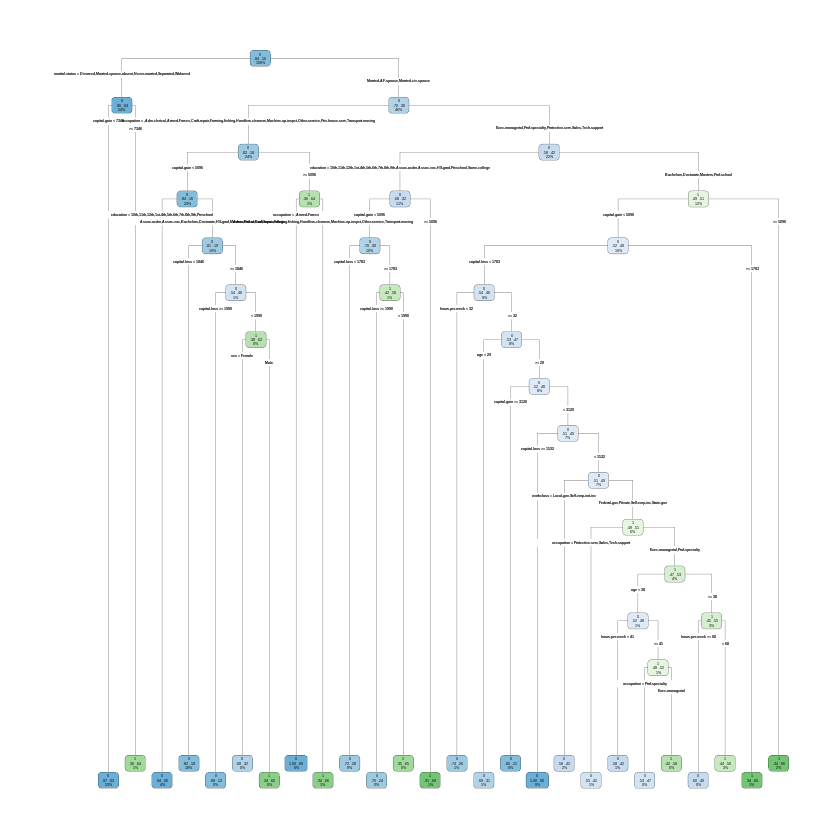

In [44]:
tree_model <- rpart(as.factor(income) ~ ., data = adult, method = "class", control = rpart.control(cp = 0.001))

rpart.plot(tree_model, extra = 104, fallen.leaves = TRUE, type = 4, tweak = 1.2)


Classification tree:
rpart(formula = as.factor(income) ~ ., data = adult, method = "class")

Variables actually used in tree construction:
[1] capital.gain   capital.loss   education      marital.status occupation    

Root node error: 7508/46443 = 0.16166

n= 46443 

        CP nsplit rel error  xerror     xstd
1 0.012009      0   1.00000 1.00000 0.010567
2 0.010000      8   0.88772 0.89371 0.010091


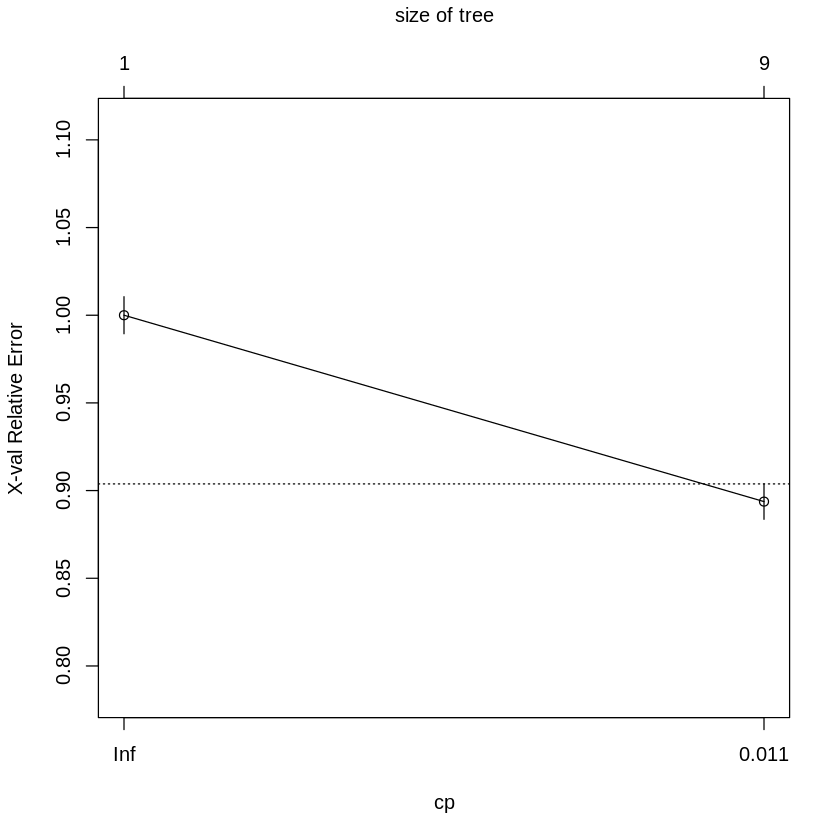

In [29]:
printcp(tree_model)
plotcp(tree_model)

best_cp <- tree_model$cptable[which.min(tree_model$cptable[, "xerror"]), "CP"]

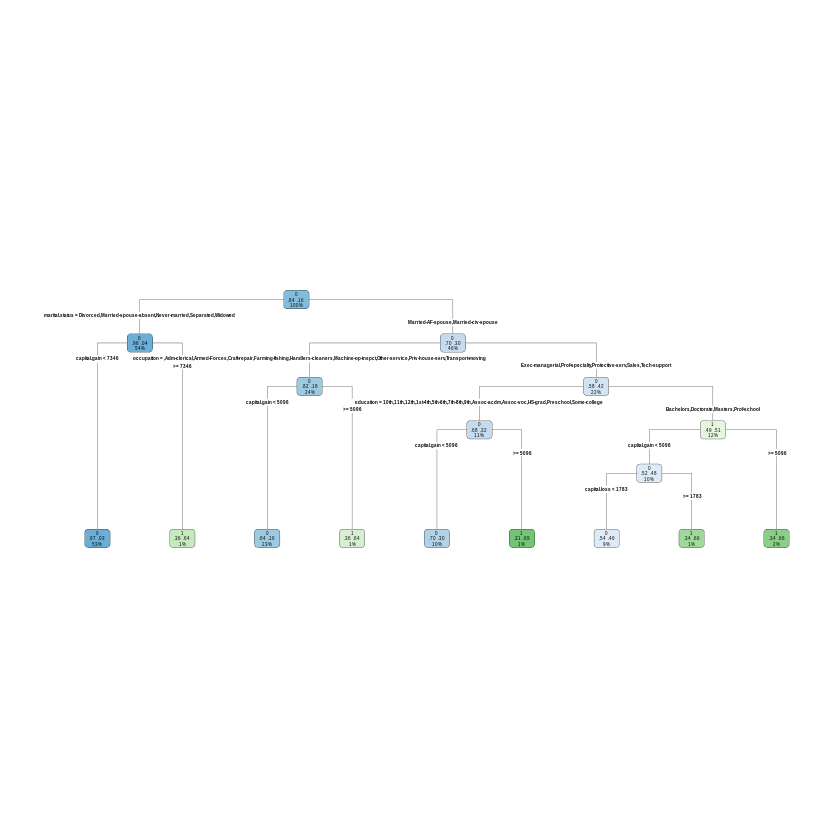

In [48]:
pruned_tree <- prune(tree_model, cp = best_cp)

rpart.plot(pruned_tree, extra = 104, fallen.leaves = TRUE, type = 4, tweak = 1.2)


In [45]:
pred_tree <- predict(tree_model, type = "class")
acc_tree <- mean(pred_tree == adult$income)

pred_pruned <- predict(pruned_tree, type = "class")
acc_pruned <- mean(pred_pruned == adult$income)

acc_tree
acc_pruned

[1] 0.8633594

[1] 0.8564908

**Compare performance before and after pruning: Althoug accuracy slightly decreases after pruning , it greatly simplifies the model by removing the less important splits. Pruning reduces the risk of overfitting and improves the model’s ability to generalize to new data. After pruning the variables that can be seen near the top are marital status, occupation, capital gain, education, sex, and age, indicating these are the most significant predictors. **

In [46]:
cat("The variables of importance are:\n")
print(tree_model$variable.importance)

The variables of importance are:
marital.status     occupation   capital.gain      education            sex 
    1489.80173      946.71884      737.26381      507.80455      497.73828 
           age hours.per.week      workclass   capital.loss           race 
     389.66331      344.35696      243.69456      200.75701        3.29336 


# Part 6: Bagging (5 points)

Implement bagging (bootstrap aggregation). (2 pts)

Compare performance with a single tree. (2 pts)

Explain why bagging improves model performance. (1 pt)

In [41]:
bag_model <- randomForest(as.factor(income) ~ .,
                          data = adult,
                          mtry = ncol(adult) - 1)

bag_pred_train <- predict(bag_model, newdata = adult)
acc_bag <- mean(bag_pred_train == adult$income)
acc_bag

[1] 0.9708675


Call:
 randomForest(formula = as.factor(income) ~ ., data = adult, mtry = ncol(adult) -      1) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 10

        OOB estimate of  error rate: 15.91%
Confusion matrix:
      0    1 class.error
0 36098 2837  0.07286503
1  4554 2954  0.60655301

,MeanDecreaseGini
age,2783.5006
workclass,747.7873
education,1200.4506
occupation,1394.8223
hours.per.week,1644.3498
capital.gain,1025.2187
capital.loss,373.7235
sex,246.6673
race,327.2369
marital.status,1627.9726


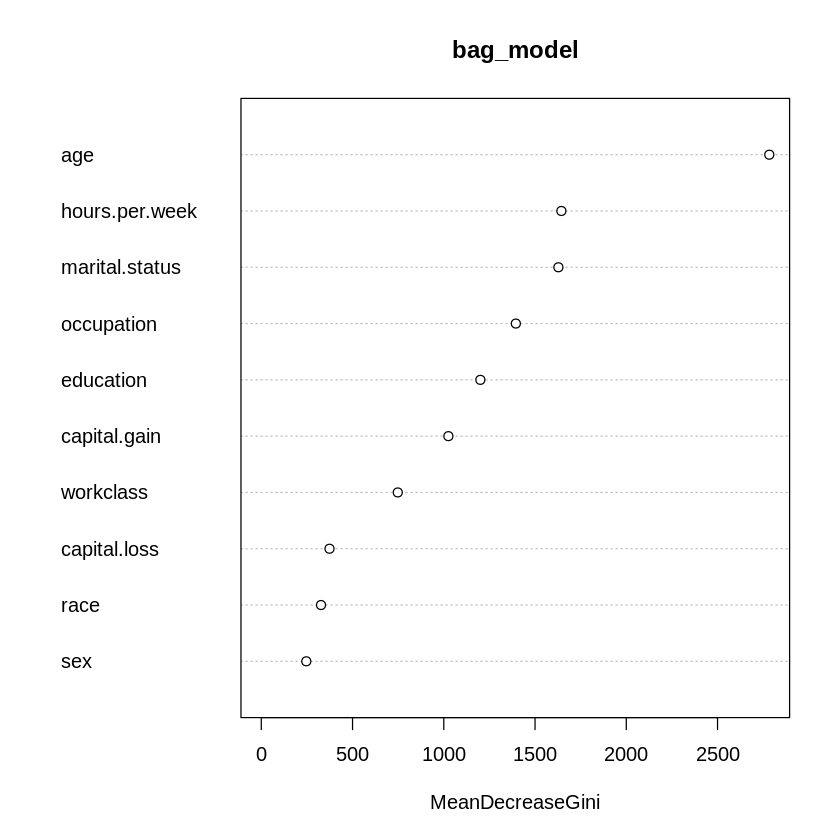

In [50]:
bag_model

importance(bag_model)
varImpPlot(bag_model)

In [42]:
acc_pruned
acc_bag

[1] 0.8564908

[1] 0.9708675

**Explain why bagging improves model performance: As shown accuracy was greatly improved compared to the accuracy of the tree model. This is because bagging combines multiple decision trees which are trained on different subsets of the data. This leads to (1) Variance Reduction - as bagging averages many trees leading to a reduced variability (2) Improved Stability - averaging each tree which all capture different patternss leads to more consistent predictions (3) Reduced Overfitting - as shown in the full tree model, tree models may be prone to overfitting but averaging them helps generalize better (4) Random resampling of the dataset - as each tree is trained on randomly resampled version of the dataset, which creates variation.**